# BÀI TẬP THỰC HÀNH MÔN NHẬP MÔN PHÂN TÍCH DỮ LIỆU VÀ HỌC SÂU

###  Chuẩn bị dữ liệu cho bài toán phân loại: 

In [1]:
from torchvision import datasets 
import torch 
data_folder = '~/data/FMNIST' # This can be any directory you want  
# to download FMNIST to 
fmnist = datasets.FashionMNIST(data_folder, download=True, train=True) 

In [2]:
tr_images = fmnist.data
tr_targets = fmnist.targets

### Kiểm tra các tensor mà chúng ta đang xử lý: 

In [3]:
unique_values = tr_targets.unique()
print(f'tr_images & tr_targets:\n\tX - {tr_images.shape}\n\tY - {tr_targets.shape}  \n \t Y - Unique Values : {unique_values}')
print(f'TASK:\n\t{len(unique_values)} class Classification') 
print(f'UNIQUE CLASSES:\n\t{fmnist.classes}')

tr_images & tr_targets:
	X - torch.Size([60000, 28, 28])
	Y - torch.Size([60000])  
 	 Y - Unique Values : tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
TASK:
	10 class Classification
UNIQUE CLASSES:
	['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [4]:
import matplotlib.pyplot as plt
%matplotlib inline 
import numpy as np 

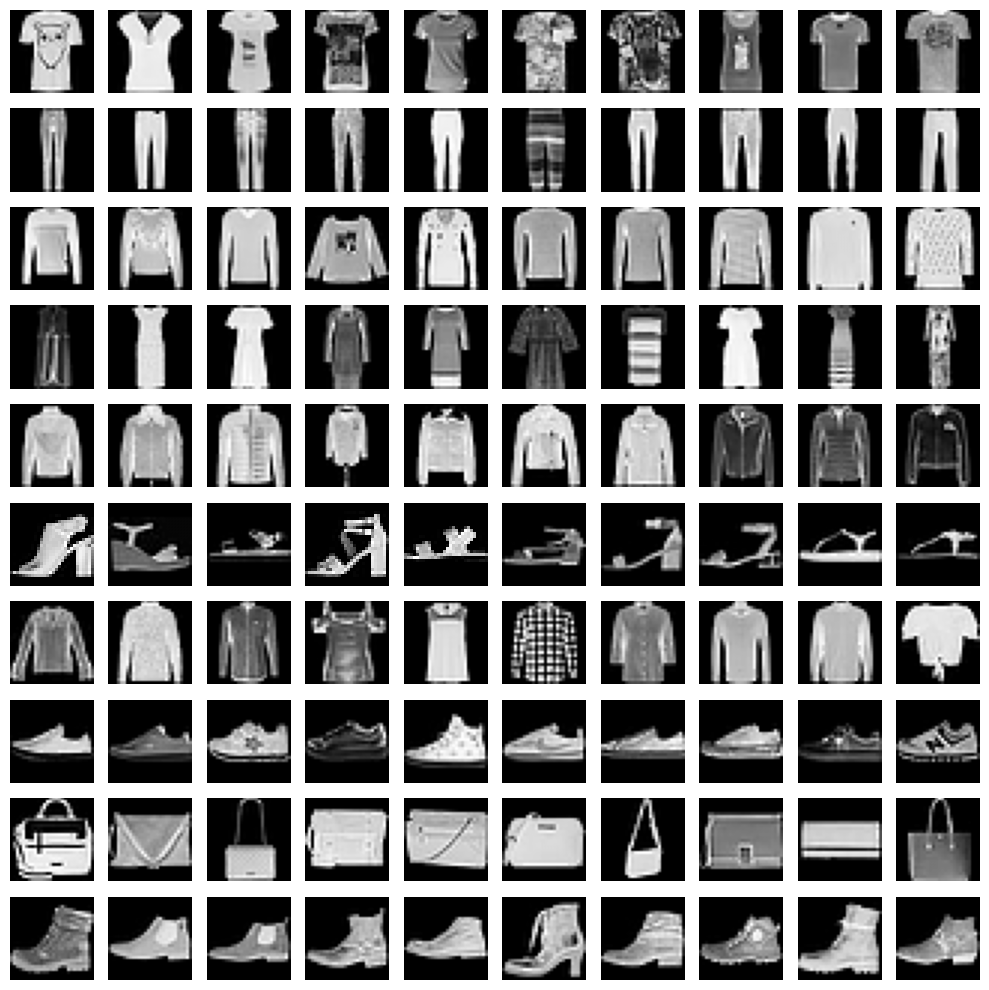

In [5]:
R, C = len(tr_targets.unique()), 10 
fig, ax = plt.subplots(R, C, figsize=(10,10)) 
for label_class, plot_row in enumerate(ax): 
    label_x_rows = np.where(tr_targets == label_class)[0] 
    for plot_cell in plot_row: 
        plot_cell.grid(False); plot_cell.axis('off') 
        ix = np.random.choice(label_x_rows) 
        x, y = tr_images[ix], tr_targets[ix] 
        plot_cell.imshow(x, cmap='gray') 
plt.tight_layout()

 ### Huấn luyện mạng nơ-ron 

#### 1. Import các gói có liên quan và bộ dữ liệu FMNIST: 

In [6]:
from torch.utils.data import Dataset, DataLoader 
import torch 
import torch.nn as nn 
import numpy as np 
import matplotlib.pyplot as plt 
%matplotlib inline 
device = "cuda" if torch.cuda.is_available() else "cpu" 
print(device)
from torchvision import datasets 
data_folder = '~/data/FMNIST' # This can be any directory you want to  
# download FMNIST to 
fmnist = datasets.FashionMNIST(data_folder, download=True, train=True) 
tr_images = fmnist.data 
tr_targets = fmnist.targets

cuda


#### 2. Xây dựng một lớp tìm nạp tập dữ liệu. Chúng ta cần ba hàm __init__,__getitem__ và __len__: 

In [7]:
class FMNISTDataset(Dataset):
    def __init__(self, x, y): 
        x = x.float() 
        x = x.view(-1,28*28) 
        self.x, self.y = x, y  
    def __getitem__(self, ix): 
        x, y = self.x[ix], self.y[ix]  
        return x.to(device), y.to(device) 
    def __len__(self):  
        return len(self.x)

####  3. Tạo một hàm tạo DataLoader – trn_dl từ tập dữ liệu – được gọi là FMNISTDataset. Điều này sẽ lấy mẫu 32 ảnh ngẫu nhiên  cho kích thước bó: 

In [8]:
def get_data():  
    train = FMNISTDataset(tr_images, tr_targets)  
    trn_dl = DataLoader(train, batch_size=32, shuffle=True) 
    return trn_dl 


#### 4. Xác định một mô hình, cũng như hàm sai số và trình tối ưu hóa: 

In [9]:
from torch.optim import SGD 
def get_model(): 
    model = nn.Sequential( 
        nn.Linear(28 * 28, 1000), 
        nn.ReLU(), 
        nn.Linear(1000, 10)
    ).to(device)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = SGD(model.parameters(), lr = 0.001)
    return model, loss_fn, optimizer
tr_images = fmnist.data
tr_targets = fmnist.targets

### 5. Xác định hàm sẽ huấn luyện tập dữ liệu trên một loạt hình ảnh:

In [10]:
def train_batch(x, y, model, opt, loss_fn): 
    model.train() # <- let's hold on to this until we reach dropout section 
    # call your model like any python function on your batch of inputs 
    prediction = model(x) 
    # compute loss 
    batch_loss = loss_fn(prediction, y) 
    # based on the forward pass in `model(x)` compute all the gradients of      
    # 'model.parameters()' 
    batch_loss.backward() 
    # apply new-weights = f(old-weights, old-weight-gradients) where  
    # "f" is the optimizer 
    optimizer.step() 
    # Flush gradients memory for next batch of calculations 
    optimizer.zero_grad() 
    return batch_loss.item() 

In [11]:
# since there's no need for updating weights, 
# we might as well not compute the gradients. 
# Using this '@' decorator on top of functions 
# will disable gradient computation in the entire function 
@torch.no_grad() 
def accuracy(x, y, model): 
    model.eval() # <- let's wait till we get to dropout section 
    # get the prediction matrix for a tensor of `x` images 
    prediction = model(x) 
    # compute if the location of maximum in each row coincides  
    # with ground truth 
    max_values, argmaxes = prediction.max(-1) 
    is_correct = argmaxes == y 
    return is_correct.cpu().numpy().tolist() 

0
1
2
3
4
5
6
7
8
9


C:\Users\T.Hung\AppData\Local\Temp\ipykernel_26668\3703903564.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in


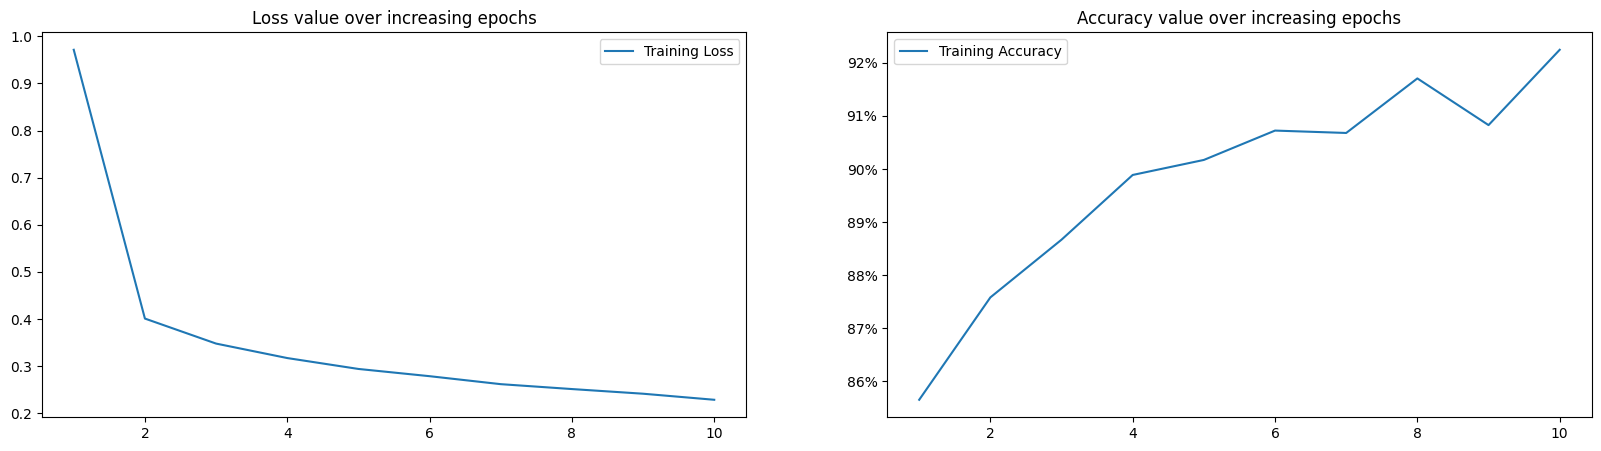

In [12]:
trn_dl = get_data() 
model, loss_fn, optimizer = get_model() 
losses, accuracies = [], [] 
for epoch in range(10): 
    print(epoch) 
    epoch_losses, epoch_accuracies = [], [] 
    for ix, batch in enumerate(iter(trn_dl)): 
        x, y = batch 
        batch_loss = train_batch(x, y, model, optimizer, loss_fn) 
        epoch_losses.append(batch_loss) 
    epoch_loss = np.array(epoch_losses).mean() 
    for ix, batch in enumerate(iter(trn_dl)): 
        x, y = batch 
        is_correct = accuracy(x, y, model) 
        epoch_accuracies.extend(is_correct) 
    epoch_accuracy = np.mean(epoch_accuracies) 
    losses.append(epoch_loss) 
    accuracies.append(epoch_accuracy) 
epochs = np.arange(10)+1 
plt.figure(figsize=(20,5)) 
plt.subplot(121) 
plt.title('Loss value over increasing epochs') 
plt.plot(epochs, losses, label='Training Loss') 
plt.legend() 
plt.subplot(122) 
plt.title('Accuracy value over increasing epochs') 
plt.plot(epochs, accuracies, label='Training Accuracy') 
plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in 
plt.gca().get_yticks()])  
plt.legend()

### 3. Chia tỉ lệ tập dữ liệu để cải thiện độ chính xác của mô hình
#### 1. Tìm nạp tập dữ liệu cũng như các hình ảnh và gán nhãn vào biến tr_targets như chúng ta đã làm trong phần trước: 

In [13]:
from torch.utils.data import Dataset, DataLoader 
import torch 
import torch.nn as nn 
import numpy as np 
import matplotlib.pyplot as plt 
%matplotlib inline 
device = "cuda" if torch.cuda.is_available() else "cpu" 
print(device)
from torchvision import datasets 
data_folder = '~/data/FMNIST' # This can be any directory you want to  
# download FMNIST to 
fmnist = datasets.FashionMNIST(data_folder, download=True, train=True) 
tr_images = fmnist.data 
tr_targets = fmnist.targets

cuda


#### 2. Sửa đổi FMNISTDataset để tìm nạp dữ liệu sao cho hình ảnh đầu vào được chia cho 255 (cường độ/giá trị tối đa của pixel): 

In [14]:
class FMNISTDataset(Dataset): 
    def __init__(self, x, y): 
        x = x.float()/255 
        x = x.view(-1,28*28) 
        self.x, self.y = x, y  
    def __getitem__(self, ix): 
        x, y = self.x[ix], self.y[ix]  
        return x.to(device), y.to(device) 
    def __len__(self):  
        return len(self.x) 

####  3. Huấn luyện một mô hình, giống như chúng ta đã làm ở các bước 4, 5, 6 và 7 của phần trước: 

In [15]:
def get_data():
  train = FMNISTDataset(tr_images, tr_targets)
  trn_dl = DataLoader(train, batch_size=32, shuffle=True)
  return trn_dl

from torch.optim import SGD
def get_model():
  model = nn.Sequential(
    nn.Linear(28 * 28, 1000),
    nn.ReLU(),
    nn.Linear(1000, 10)
  ).to(device)
  loss_fn = nn.CrossEntropyLoss()
  optimizer = SGD(model.parameters(), lr=1e-2)
  return model, loss_fn, optimizer

def train_batch(x, y, model, opt, loss_fn):
    model.train()
    prediction = model(x)
    batch_loss = loss_fn(prediction, y)
    batch_loss.backward()
    opt.step()
    opt.zero_grad()
    return batch_loss.item()

def accuracy(x, y, model):
  model.eval()
  with torch.no_grad():
    prediction = model(x)
  max_values, argmaxes = prediction.max(-1)
  is_correct = argmaxes == y
  return is_correct.cpu().numpy().tolist()

trn_dl = get_data()
model, loss_fn, optimizer = get_model()
losses, accuracies = [], []

for epoch in range(5):
  print(f"{epoch}")
  epoch_losses, epoch_accuracies = [], []
  for ix, batch in enumerate(iter(trn_dl)):
    x, y = batch
    batch_loss = train_batch(x, y, model, optimizer, loss_fn)
    epoch_losses.append(batch_loss)
  
  epoch_loss = np.array(epoch_losses).mean()
  
  for ix, batch in enumerate(iter(trn_dl)):
    x, y = batch
    is_correct = accuracy(x, y, model)
    epoch_accuracies.extend(is_correct)
  
  epoch_accuracy = np.mean(epoch_accuracies)
  
  # These must be indented to be inside the epoch loop
  losses.append(epoch_loss)
  accuracies.append(epoch_accuracy)

0
1
2
3
4


C:\Users\T.Hung\AppData\Local\Temp\ipykernel_26668\1906818568.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])


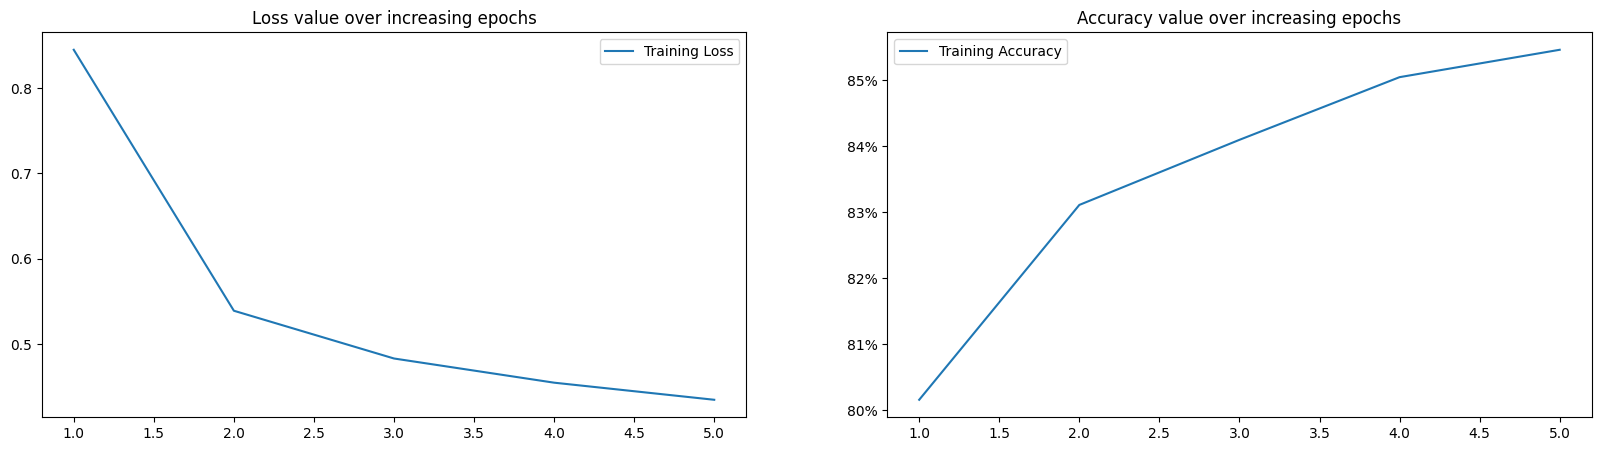

In [16]:
epochs = np.arange(5)+1
import matplotlib.pyplot as plt
%matplotlib inline
plt.figure(figsize=(20,5))
plt.subplot(121)
plt.title('Loss value over increasing epochs')
plt.plot(epochs, losses, label='Training Loss')
plt.legend()
plt.subplot(122)
plt.title('Accuracy value over increasing epochs')
plt.plot(epochs, accuracies, label='Training Accuracy')
plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])
plt.legend()
plt.show()

### 4. Hiểu được tác động của việc thay đổi kích thước bó 

#### Kích thước bó 32 
#### 1. Tải xuống và import các hình ảnh huấn luyện và gán nhãn vào biến tr_targets: 

In [17]:
from torchvision import datasets 
import torch 
data_folder = '~/data/FMNIST' # This can be any directory you want to  
# download FMNIST to 
fmnist = datasets.FashionMNIST(data_folder, download=True, train=True) 
tr_images = fmnist.data 
tr_targets = fmnist.targets 

#### 2. Theo cách tương tự với hình ảnh huấn luyện, chúng ta phải tải xuống và nhập tập dữ liệu xác thực bằng cách chỉ định train = False trong khi gọi phương thức FashionMNIST trong bộ dữ liệu của chúng ta: 

C:\Users\T.Hung\AppData\Local\Temp\ipykernel_26668\2774615174.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in


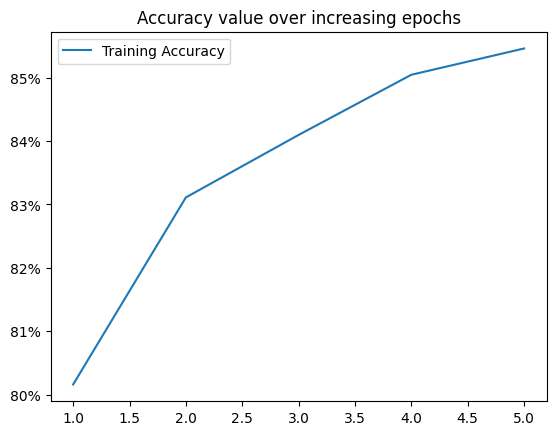

In [18]:
val_fmnist = datasets.FashionMNIST(data_folder, download=True, train=False) 
val_images = val_fmnist.data 
val_targets = val_fmnist.targets 
plt.title('Accuracy value over increasing epochs') 
plt.plot(epochs, accuracies, label='Training Accuracy') 
plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in 
plt.gca().get_yticks()])  
plt.legend() 

#### 3. Import các gói có liên quan và xác định thiết bị:

In [19]:
import matplotlib.pyplot as plt 
%matplotlib inline 
import numpy as np 
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
device = 'cuda' if torch.cuda.is_available() else 'cpu'


#### 4. Xác định lớp tập dữ liệu (FashionMNIST), các hàm sẽ được sử dụng để huấn luyện trên một bó dữ liệu (train_batch), tính toán độ chính xác (accuracy), sau đó xác định kiến trúc mô hình, hàm sai số và trình tối ưu hóa (get_model). Lưu ý rằng hàm lấy dữ liệu sẽ là hàm duy nhất có sai lệch so với những gì chúng ta đã thấy trong các phần trước (vì chúng ta hiện đang nghiên cứu các tập dữ liệu huấn luyện và xác thực), vì vậy chúng ta sẽ xây dựng nó trong bước tiếp theo: 

In [20]:
class FMNISTDataset(Dataset): 
    def __init__(self, x, y): 
        x = x.float()/255 
        x = x.view(-1,28*28) 
        self.x, self.y = x, y  
    def __getitem__(self, ix): 
        x, y = self.x[ix], self.y[ix]  
        return x.to(device), y.to(device) 
    def __len__(self):  
        return len(self.x) 
 
from torch.optim import SGD, Adam 
def get_model(): 
    model = nn.Sequential( 
        nn.Linear(28 * 28, 1000), 
        nn.ReLU(), 
        nn.Linear(1000, 10) 
    ).to(device) 
 
    loss_fn = nn.CrossEntropyLoss() 
    optimizer = Adam(model.parameters(), lr=1e-2) 
    return model, loss_fn, optimizer 
 
def train_batch(x, y, model, opt, loss_fn): 
    model.train() 
    prediction = model(x) 
    batch_loss = loss_fn(prediction, y) 
    batch_loss.backward() 
    optimizer.step() 
    optimizer.zero_grad() 
    return batch_loss.item() 
 
def accuracy(x, y, model): 
    model.eval() 
    with torch.no_grad(): 
        prediction = model(x) 
    max_values, argmaxes = prediction.max(-1) 
    is_correct = argmaxes == y 
    return is_correct.cpu().numpy().tolist()

In [21]:
def get_data():  
    train = FMNISTDataset(tr_images, tr_targets)  
    trn_dl = DataLoader(train, batch_size=32, shuffle=True) 
    val = FMNISTDataset(val_images, val_targets)  
    val_dl = DataLoader(val, batch_size=len(val_images), shuffle=False) 
    return trn_dl, val_dl

In [22]:
@torch.no_grad() 
def val_loss(x, y, model): 
    prediction = model(x) 
    val_loss = loss_fn(prediction, y) 
    return val_loss.item() 

In [23]:
trn_dl, val_dl = get_data() 
model, loss_fn, optimizer = get_model() 

In [24]:
train_losses, train_accuracies = [], [] 
val_losses, val_accuracies = [], [] 
for epoch in range(5): 
    print(epoch) 
    train_epoch_losses, train_epoch_accuracies = [], [] 
    for ix, batch in enumerate(iter(trn_dl)): 
        x, y = batch 
        batch_loss = train_batch(x, y, model, optimizer, loss_fn) 
        train_epoch_losses.append(batch_loss)  
    train_epoch_loss = np.array(train_epoch_losses).mean() 
    for ix, batch in enumerate(iter(trn_dl)): 
        x, y = batch 
        is_correct = accuracy(x, y, model) 
        train_epoch_accuracies.extend(is_correct) 
    train_epoch_accuracy = np.mean(train_epoch_accuracies) 
    for ix, batch in enumerate(iter(val_dl)): 
        x, y = batch 
        val_is_correct = accuracy(x, y, model) 
        validation_loss = val_loss(x, y, model) 
    val_epoch_accuracy = np.mean(val_is_correct) 
    train_losses.append(train_epoch_loss) 
    train_accuracies.append(train_epoch_accuracy) 
    val_losses.append(validation_loss) 
    val_accuracies.append(val_epoch_accuracy) 

0
1
2
3
4


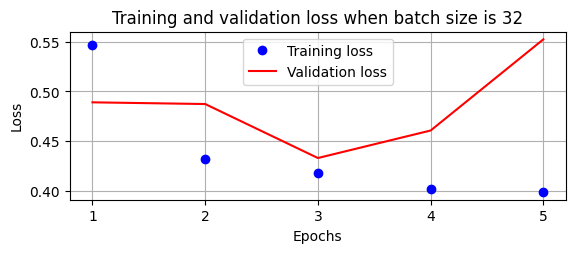

C:\Users\T.Hung\AppData\Local\Temp\ipykernel_26668\164346472.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in


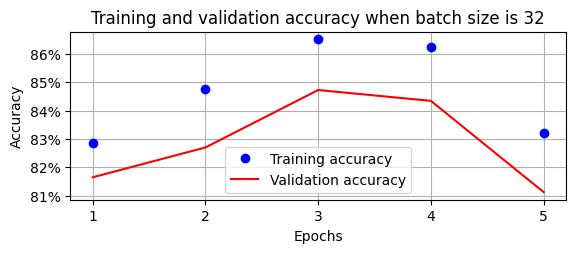

In [25]:
epochs = np.arange(5)+1 
import matplotlib.ticker as mtick 
import matplotlib.pyplot as plt 
import matplotlib.ticker as mticker 
%matplotlib inline 
plt.subplot(211) 
plt.plot(epochs, train_losses, 'bo', label='Training loss') 
plt.plot(epochs, val_losses, 'r', label='Validation loss') 
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1)) 
plt.title('Training and validation loss when batch size is 32') 
plt.xlabel('Epochs') 
plt.ylabel('Loss') 
plt.legend() 
plt.grid('off') 
plt.show() 
plt.subplot(212) 
plt.plot(epochs, train_accuracies, 'bo', label='Training accuracy') 
plt.plot(epochs, val_accuracies, 'r', label='Validation accuracy') 
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1)) 
plt.title('Training and validation accuracy when batch size is 32') 
plt.xlabel('Epochs') 
plt.ylabel('Accuracy') 
plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in 
plt.gca().get_yticks()])  
plt.legend() 
plt.grid('off')

#### Kích thước bó 10.000: Trong phần này, chúng ta sẽ sử dụng 10.000 ảnh mỗi đợt để có thể hiểu tác động của việc thay đổi quy mô bó. Chúng ta sẽ sửa đổi get_data để nó có kích thước bó là 10.000 trong khi tìm nạp DataLoader huấn luyện từ tập dữ liệu huấn luyện, như sau: 

0
1
2
3
4


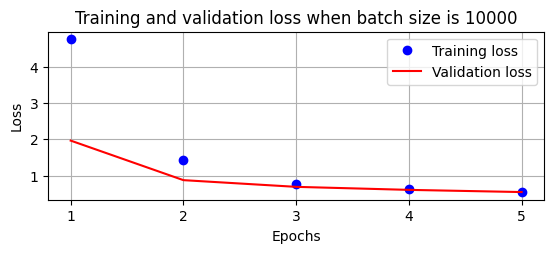

C:\Users\T.Hung\AppData\Local\Temp\ipykernel_26668\1178051704.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in


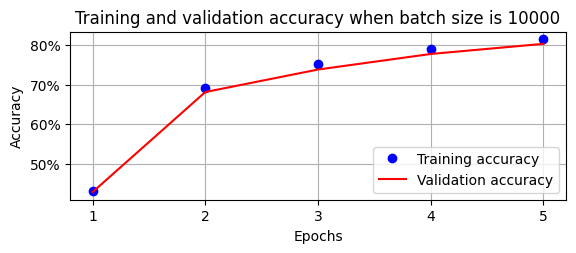

In [26]:
def get_data():  
    train = FMNISTDataset(tr_images, tr_targets)  
    trn_dl = DataLoader(train, batch_size=10000, shuffle=True) 
    val = FMNISTDataset(val_images, val_targets)  
    val_dl = DataLoader(val, batch_size=len(val_images), shuffle=False) 
    return trn_dl, val_dl 
trn_dl, val_dl = get_data() 
model, loss_fn, optimizer = get_model() 
train_losses, train_accuracies = [], [] 
val_losses, val_accuracies = [], [] 
for epoch in range(5): 
    print(epoch) 
    train_epoch_losses, train_epoch_accuracies = [], [] 
    for ix, batch in enumerate(iter(trn_dl)): 
        x, y = batch 
        batch_loss = train_batch(x, y, model, optimizer, loss_fn) 
        train_epoch_losses.append(batch_loss)  
    train_epoch_loss = np.array(train_epoch_losses).mean() 
 
    for ix, batch in enumerate(iter(trn_dl)): 
        x, y = batch 
        is_correct = accuracy(x, y, model)
    train_epoch_accuracies.extend(is_correct) 
    train_epoch_accuracy = np.mean(train_epoch_accuracies) 
    for ix, batch in enumerate(iter(val_dl)): 
        x, y = batch 
        val_is_correct = accuracy(x, y, model) 
        validation_loss = val_loss(x, y, model) 
    val_epoch_accuracy = np.mean(val_is_correct) 
    train_losses.append(train_epoch_loss) 
    train_accuracies.append(train_epoch_accuracy) 
    val_losses.append(validation_loss) 
    val_accuracies.append(val_epoch_accuracy) 
epochs = np.arange(5)+1 
import matplotlib.ticker as mtick 
import matplotlib.pyplot as plt 
import matplotlib.ticker as mticker 
%matplotlib inline 
plt.subplot(211) 
plt.plot(epochs, train_losses, 'bo', label='Training loss') 
plt.plot(epochs, val_losses, 'r', label='Validation loss') 
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1)) 
plt.title('Training and validation loss when batch size is 10000') 
plt.xlabel('Epochs') 
plt.ylabel('Loss') 
plt.legend() 
plt.grid('off') 
plt.show() 
plt.subplot(212) 
plt.plot(epochs, train_accuracies, 'bo', label='Training accuracy') 
plt.plot(epochs, val_accuracies, 'r', label='Validation accuracy') 
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1)) 
plt.title('Training and validation accuracy when batch size is 10000') 
plt.xlabel('Epochs') 
plt.ylabel('Accuracy') 
plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in 
plt.gca().get_yticks()])  
plt.legend() 
plt.grid('off') 
plt.show() 

### Hiểu được tác động của việc thay đổi trình tối ưu hóa sai số. 

In [27]:
from torchvision import datasets 
import torch 
data_folder = '~/data/FMNIST' # This can be any directory you want to  
# download FMNIST to 
fmnist = datasets.FashionMNIST(data_folder, download=True, train=True) 
tr_images = fmnist.data 
tr_targets = fmnist.targets 
val_fmnist = datasets.FashionMNIST(data_folder, download=True, train=False) 
val_images = val_fmnist.data
val_targets = val_fmnist.targets 

0
1
2
3
4
5
6
7
8
9


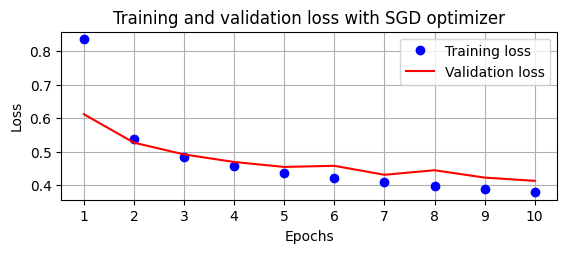

C:\Users\T.Hung\AppData\Local\Temp\ipykernel_26668\222476688.py:115: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in


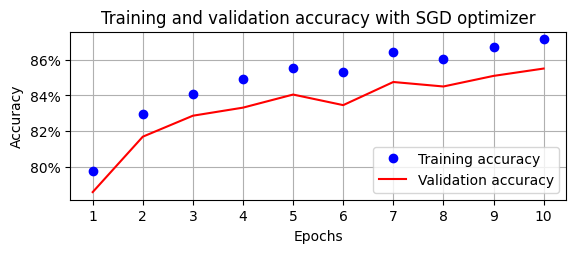

In [28]:
import matplotlib.pyplot as plt 
%matplotlib inline 
import numpy as np 
from torch.utils.data import Dataset, DataLoader 
import torch 
import torch.nn as nn 
device = 'cuda' if torch.cuda.is_available() else 'cpu' 
 
# SGD optimizer 
class FMNISTDataset(Dataset): 
    def __init__(self, x, y): 
        x = x.float()/255 
        x = x.view(-1,28*28) 
        self.x, self.y = x, y  
    def __getitem__(self, ix): 
        x, y = self.x[ix], self.y[ix]  
        return x.to(device), y.to(device) 
    def __len__(self):  
        return len(self.x) 
 
from torch.optim import SGD, Adam 
def get_model(): 
    model = nn.Sequential( 
        nn.Linear(28 * 28, 1000), 
        nn.ReLU(), 
        nn.Linear(1000, 10) 
    ).to(device) 
 
    loss_fn = nn.CrossEntropyLoss() 
    optimizer = SGD(model.parameters(), lr=1e-2) 
    return model, loss_fn, optimizer 
 
def train_batch(x, y, model, opt, loss_fn): 
    model.train() 
    prediction = model(x) 
    batch_loss = loss_fn(prediction, y) 
    batch_loss.backward() 
    optimizer.step() 
    optimizer.zero_grad() 
    return batch_loss.item() 
 
def accuracy(x, y, model):
    model.eval() 
    # this is the same as @torch.no_grad  
    # at the top of function, only difference 
    # being, grad is not computed in the with scope 
    with torch.no_grad(): 
        prediction = model(x) 
    max_values, argmaxes = prediction.max(-1) 
    is_correct = argmaxes == y 
    return is_correct.cpu().numpy().tolist() 
 
def get_data():  
    train = FMNISTDataset(tr_images, tr_targets)  
    trn_dl = DataLoader(train, batch_size=32, shuffle=True) 
    val = FMNISTDataset(val_images, val_targets)  
    val_dl = DataLoader(val, batch_size=len(val_images), shuffle=False) 
    return trn_dl, val_dl 
@torch.no_grad() 
def val_loss(x, y, model): 
    prediction = model(x) 
    val_loss = loss_fn(prediction, y) 
    return val_loss.item() 
trn_dl, val_dl = get_data() 
model, loss_fn, optimizer = get_model() 
 
train_losses, train_accuracies = [], [] 
val_losses, val_accuracies = [], [] 
for epoch in range(10): 
    print(epoch) 
    train_epoch_losses, train_epoch_accuracies = [], [] 
    for ix, batch in enumerate(iter(trn_dl)): 
        x, y = batch 
        batch_loss = train_batch(x, y, model, optimizer, loss_fn) 
        train_epoch_losses.append(batch_loss)  
    train_epoch_loss = np.array(train_epoch_losses).mean() 
 
    for ix, batch in enumerate(iter(trn_dl)): 
        x, y = batch 
        is_correct = accuracy(x, y, model) 
        train_epoch_accuracies.extend(is_correct) 
    train_epoch_accuracy = np.mean(train_epoch_accuracies) 
    for ix, batch in enumerate(iter(val_dl)): 
        x, y = batch 
        val_is_correct = accuracy(x, y, model) 
        validation_loss = val_loss(x, y, model)
        val_epoch_accuracy = np.mean(val_is_correct) 
    train_losses.append(train_epoch_loss) 
    train_accuracies.append(train_epoch_accuracy) 
    val_losses.append(validation_loss) 
    val_accuracies.append(val_epoch_accuracy) 
 
epochs = np.arange(10)+1 
import matplotlib.ticker as mtick 
import matplotlib.pyplot as plt 
import matplotlib.ticker as mticker 
%matplotlib inline 
plt.subplot(211) 
plt.plot(epochs, train_losses, 'bo', label='Training loss') 
plt.plot(epochs, val_losses, 'r', label='Validation loss') 
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1)) 
plt.title('Training and validation loss with SGD optimizer') 
plt.xlabel('Epochs') 
plt.ylabel('Loss') 
plt.legend() 
plt.grid('off') 
plt.show() 
plt.subplot(212) 
plt.plot(epochs, train_accuracies, 'bo', label='Training accuracy') 
plt.plot(epochs, val_accuracies, 'r', label='Validation accuracy') 
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1)) 
plt.title('Training and validation accuracy with SGD optimizer') 
plt.xlabel('Epochs') 
plt.ylabel('Accuracy') 
plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in 
plt.gca().get_yticks()])  
plt.legend() 
plt.grid('off') 
plt.show() 

### Adam optimizer

0
1
2
3
4
5
6
7
8
9


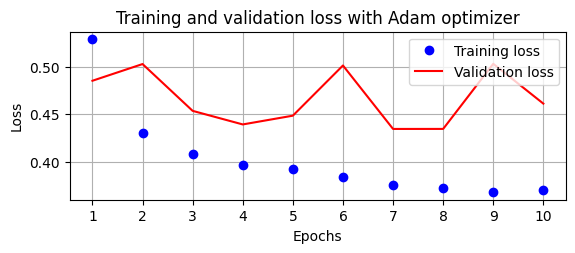

C:\Users\T.Hung\AppData\Local\Temp\ipykernel_26668\3923024356.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in


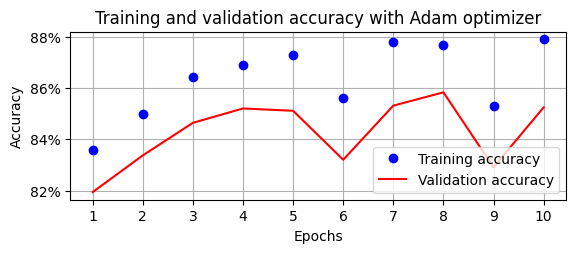

In [29]:
from torch.optim import SGD, Adam 
def get_model(): 
    model = nn.Sequential( 
        nn.Linear(28 * 28, 1000), 
        nn.ReLU(), 
        nn.Linear(1000, 10) 
    ).to(device) 
 
    loss_fn = nn.CrossEntropyLoss() 
    optimizer = Adam(model.parameters(), lr=1e-2) 
    return model, loss_fn, optimizer 
trn_dl, val_dl = get_data() 
model, loss_fn, optimizer = get_model() 
 
train_losses, train_accuracies = [], [] 
val_losses, val_accuracies = [], [] 
for epoch in range(10): 
    print(epoch) 
    train_epoch_losses, train_epoch_accuracies = [], [] 
    for ix, batch in enumerate(iter(trn_dl)): 
        x, y = batch 
        batch_loss = train_batch(x, y, model, optimizer, loss_fn) 
        train_epoch_losses.append(batch_loss)  
    train_epoch_loss = np.array(train_epoch_losses).mean() 
 
    for ix, batch in enumerate(iter(trn_dl)): 
        x, y = batch 
        is_correct = accuracy(x, y, model) 
        train_epoch_accuracies.extend(is_correct) 
    train_epoch_accuracy = np.mean(train_epoch_accuracies) 
    for ix, batch in enumerate(iter(val_dl)): 
        x, y = batch 
        val_is_correct = accuracy(x, y, model) 
        validation_loss = val_loss(x, y, model) 
    val_epoch_accuracy = np.mean(val_is_correct) 
    train_losses.append(train_epoch_loss) 
    train_accuracies.append(train_epoch_accuracy) 
    val_losses.append(validation_loss) 
    val_accuracies.append(val_epoch_accuracy) 
epochs = np.arange(10)+1 
import matplotlib.ticker as mtick 
import matplotlib.pyplot as plt 
import matplotlib.ticker as mticker 
%matplotlib inline 
plt.subplot(211) 
plt.plot(epochs, train_losses, 'bo', label='Training loss') 
plt.plot(epochs, val_losses, 'r', label='Validation loss') 
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1)) 
plt.title('Training and validation loss with Adam optimizer') 
plt.xlabel('Epochs') 
plt.ylabel('Loss') 
plt.legend() 
plt.grid('off') 
plt.show() 
plt.subplot(212) 
plt.plot(epochs, train_accuracies, 'bo', label='Training accuracy') 
plt.plot(epochs, val_accuracies, 'r', label='Validation accuracy') 
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1)) 
plt.title('Training and validation accuracy with Adam optimizer') 
plt.xlabel('Epochs') 
plt.ylabel('Accuracy') 
plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in 
plt.gca().get_yticks()])  
plt.legend() 
plt.grid('off') 
plt.show()

Tác động của tốc độ học lên tập dữ liệu được chia tỷ lệ 

0
1
2
3
4


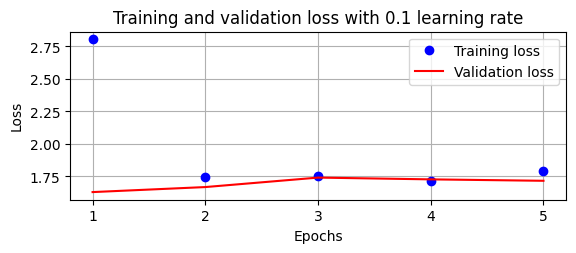

C:\Users\T.Hung\AppData\Local\Temp\ipykernel_26668\2012562699.py:126: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in


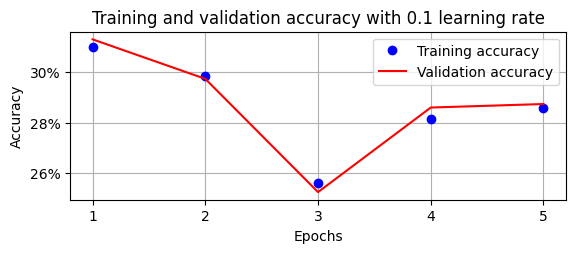

In [30]:
from torchvision import datasets 
import torch 
data_folder = '~/data/FMNIST' # This can be any directory you want to  
# download FMNIST to 
fmnist = datasets.FashionMNIST(data_folder, download=True, train=True) 
tr_images = fmnist.data 
tr_targets = fmnist.targets 
val_fmnist = datasets.FashionMNIST(data_folder, download=True, train=False) 
val_images = val_fmnist.data
val_targets = val_fmnist.targets 
 
import matplotlib.pyplot as plt 
%matplotlib inline 
import numpy as np 
from torch.utils.data import Dataset, DataLoader 
import torch 
import torch.nn as nn 
device = 'cuda' if torch.cuda.is_available() else 'cpu' 
 
# High Learning Rate 
class FMNISTDataset(Dataset): 
    def __init__(self, x, y): 
        x = x.float()/255 
        x = x.view(-1,28*28) 
        self.x, self.y = x, y  
    def __getitem__(self, ix): 
        x, y = self.x[ix], self.y[ix]  
        return x.to(device), y.to(device) 
    def __len__(self):  
        return len(self.x) 
 
from torch.optim import SGD, Adam 
def get_model(): 
    model = nn.Sequential( 
        nn.Linear(28 * 28, 1000), 
        nn.ReLU(), 
        nn.Linear(1000, 10) 
    ).to(device) 
 
    loss_fn = nn.CrossEntropyLoss() 
    optimizer = Adam(model.parameters(), lr=1e-1) 
    return model, loss_fn, optimizer 
 
def train_batch(x, y, model, opt, loss_fn): 
    model.train() 
    prediction = model(x) 
    batch_loss = loss_fn(prediction, y) 
    batch_loss.backward() 
    optimizer.step() 
    optimizer.zero_grad() 
    return batch_loss.item() 
 
def accuracy(x, y, model):
    model.eval() 
    # this is the same as @torch.no_grad  
    # at the top of function, only difference 
    # being, grad is not computed in the with scope 
    with torch.no_grad(): 
        prediction = model(x) 
    max_values, argmaxes = prediction.max(-1) 
    is_correct = argmaxes == y 
    return is_correct.cpu().numpy().tolist() 
def get_data():  
    train = FMNISTDataset(tr_images, tr_targets)  
    trn_dl = DataLoader(train, batch_size=32, shuffle=True) 
    val = FMNISTDataset(val_images, val_targets)  
    val_dl = DataLoader(val, batch_size=len(val_images), shuffle=False) 
    return trn_dl, val_dl 
 
@torch.no_grad() 
def val_loss(x, y, model): 
    prediction = model(x) 
    val_loss = loss_fn(prediction, y) 
    return val_loss.item() 
 
trn_dl, val_dl = get_data() 
model, loss_fn, optimizer = get_model() 
 
train_losses, train_accuracies = [], [] 
val_losses, val_accuracies = [], [] 
for epoch in range(5): 
    print(epoch) 
    train_epoch_losses, train_epoch_accuracies = [], [] 
    for ix, batch in enumerate(iter(trn_dl)): 
        x, y = batch 
        batch_loss = train_batch(x, y, model, optimizer, loss_fn) 
        train_epoch_losses.append(batch_loss)  
    train_epoch_loss = np.array(train_epoch_losses).mean() 
 
    for ix, batch in enumerate(iter(trn_dl)): 
        x, y = batch 
        is_correct = accuracy(x, y, model) 
        train_epoch_accuracies.extend(is_correct) 
    train_epoch_accuracy = np.mean(train_epoch_accuracies) 
    for ix, batch in enumerate(iter(val_dl)): 
        x, y = batch 
        val_is_correct = accuracy(x, y, model) 
        validation_loss = val_loss(x, y, model) 
    val_epoch_accuracy = np.mean(val_is_correct) 
    train_losses.append(train_epoch_loss) 
    train_accuracies.append(train_epoch_accuracy) 
    val_losses.append(validation_loss) 
    val_accuracies.append(val_epoch_accuracy) 
epochs = np.arange(5)+1 
import matplotlib.ticker as mtick 
import matplotlib.pyplot as plt 
import matplotlib.ticker as mticker 
%matplotlib inline 
plt.subplot(211) 
plt.plot(epochs, train_losses, 'bo', label='Training loss') 
plt.plot(epochs, val_losses, 'r', label='Validation loss') 
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1)) 
plt.title('Training and validation loss with 0.1 learning rate') 
plt.xlabel('Epochs') 
plt.ylabel('Loss') 
plt.legend() 
plt.grid('off') 
plt.show() 
plt.subplot(212) 
plt.plot(epochs, train_accuracies, 'bo', label='Training accuracy') 
plt.plot(epochs, val_accuracies, 'r', label='Validation accuracy') 
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1)) 
plt.title('Training and validation accuracy with 0.1 learning rate') 
plt.xlabel('Epochs') 
plt.ylabel('Accuracy') 
plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in 
plt.gca().get_yticks()])  
plt.legend() 
plt.grid('off') 
plt.show() 

Tốc độ học trung bình

0
1
2
3
4


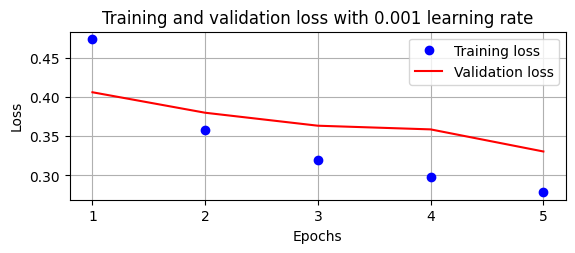

C:\Users\T.Hung\AppData\Local\Temp\ipykernel_26668\377606895.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in


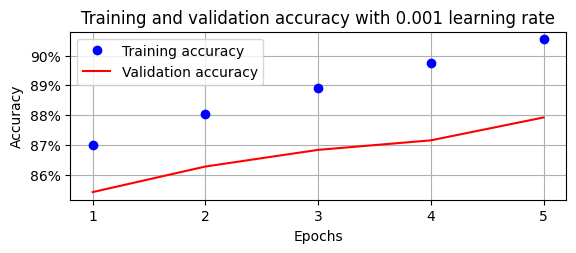

In [31]:
def get_model(): 
    model = nn.Sequential( 
        nn.Linear(28 * 28, 1000), 
        nn.ReLU(), 
        nn.Linear(1000, 10) 
    ).to(device) 
 
    loss_fn = nn.CrossEntropyLoss() 
    optimizer = Adam(model.parameters(), lr=1e-3) 
    return model, loss_fn, optimizer 
trn_dl, val_dl = get_data() 
model, loss_fn, optimizer = get_model() 
 
train_losses, train_accuracies = [], [] 
val_losses, val_accuracies = [], [] 
for epoch in range(5): 
    print(epoch) 
    train_epoch_losses, train_epoch_accuracies = [], [] 
    for ix, batch in enumerate(iter(trn_dl)): 
        x, y = batch
        batch_loss = train_batch(x, y, model, optimizer, loss_fn) 
        train_epoch_losses.append(batch_loss)  
    train_epoch_loss = np.array(train_epoch_losses).mean() 
 
    for ix, batch in enumerate(iter(trn_dl)): 
        x, y = batch 
        is_correct = accuracy(x, y, model) 
        train_epoch_accuracies.extend(is_correct) 
    train_epoch_accuracy = np.mean(train_epoch_accuracies) 
    for ix, batch in enumerate(iter(val_dl)): 
        x, y = batch 
        val_is_correct = accuracy(x, y, model) 
        validation_loss = val_loss(x, y, model) 
    val_epoch_accuracy = np.mean(val_is_correct) 
    train_losses.append(train_epoch_loss) 
    train_accuracies.append(train_epoch_accuracy) 
    val_losses.append(validation_loss) 
    val_accuracies.append(val_epoch_accuracy) 
 
epochs = np.arange(5)+1 
import matplotlib.ticker as mtick 
import matplotlib.pyplot as plt 
import matplotlib.ticker as mticker 
%matplotlib inline 
plt.subplot(211) 
plt.plot(epochs, train_losses, 'bo', label='Training loss') 
plt.plot(epochs, val_losses, 'r', label='Validation loss') 
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1)) 
plt.title('Training and validation loss with 0.001 learning rate') 
plt.xlabel('Epochs') 
plt.ylabel('Loss') 
plt.legend() 
plt.grid('off') 
plt.show() 
plt.subplot(212) 
plt.plot(epochs, train_accuracies, 'bo', label='Training accuracy') 
plt.plot(epochs, val_accuracies, 'r', label='Validation accuracy') 
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1)) 
plt.title('Training and validation accuracy with 0.001 learning rate') 
plt.xlabel('Epochs') 
plt.ylabel('Accuracy') 
plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in 
plt.gca().get_yticks()])  
plt.legend() 
plt.grid('off') 
plt.show()


Tốc độ học thấp 

0
1
2
3
4


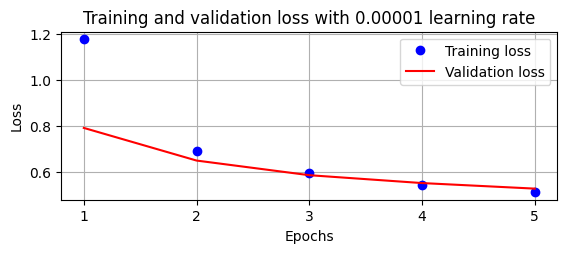

C:\Users\T.Hung\AppData\Local\Temp\ipykernel_26668\1359133767.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in


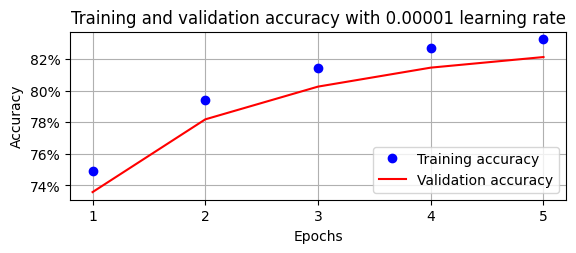

In [32]:
def get_model(): 
    model = nn.Sequential( 
        nn.Linear(28 * 28, 1000), 
        nn.ReLU(), 
        nn.Linear(1000, 10) 
    ).to(device) 
 
    loss_fn = nn.CrossEntropyLoss() 
    optimizer = Adam(model.parameters(), lr=1e-5) 
    return model, loss_fn, optimizer  
 
trn_dl, val_dl = get_data() 
model, loss_fn, optimizer = get_model() 
 
train_losses, train_accuracies = [], [] 
val_losses, val_accuracies = [], [] 
for epoch in range(5): 
    print(epoch) 
    train_epoch_losses, train_epoch_accuracies = [], [] 
    for ix, batch in enumerate(iter(trn_dl)): 
        x, y = batch 
        batch_loss = train_batch(x, y, model, optimizer, loss_fn)
        train_epoch_losses.append(batch_loss)  
    train_epoch_loss = np.array(train_epoch_losses).mean() 
    for ix, batch in enumerate(iter(trn_dl)): 
        x, y = batch 
        is_correct = accuracy(x, y, model) 
        train_epoch_accuracies.extend(is_correct) 
    train_epoch_accuracy = np.mean(train_epoch_accuracies) 
    for ix, batch in enumerate(iter(val_dl)): 
        x, y = batch 
        val_is_correct = accuracy(x, y, model) 
        validation_loss = val_loss(x, y, model) 
    val_epoch_accuracy = np.mean(val_is_correct) 
    train_losses.append(train_epoch_loss) 
    train_accuracies.append(train_epoch_accuracy) 
    val_losses.append(validation_loss) 
    val_accuracies.append(val_epoch_accuracy) 
epochs = np.arange(5)+1 
import matplotlib.ticker as mtick 
import matplotlib.pyplot as plt 
import matplotlib.ticker as mticker 
%matplotlib inline 
plt.subplot(211) 
plt.plot(epochs, train_losses, 'bo', label='Training loss') 
plt.plot(epochs, val_losses, 'r', label='Validation loss') 
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1)) 
plt.title('Training and validation loss with 0.00001 learning rate') 
plt.xlabel('Epochs') 
plt.ylabel('Loss') 
plt.legend() 
plt.grid('off') 
plt.show() 
plt.subplot(212) 
plt.plot(epochs, train_accuracies, 'bo', label='Training accuracy') 
plt.plot(epochs, val_accuracies, 'r', label='Validation accuracy') 
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1)) 
plt.title('Training and validation accuracy with 0.00001 learning rate') 
plt.xlabel('Epochs') 
plt.ylabel('Accuracy') 
plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in 
plt.gca().get_yticks()])  
plt.legend() 
plt.grid('off') 
plt.show() 

Tác động của việc thay đổi tốc độ học trên tập dữ liệu không được chia tỷ lệ

0
1
2
3
4


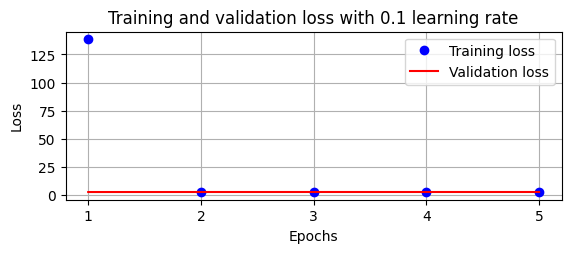

C:\Users\T.Hung\AppData\Local\Temp\ipykernel_26668\2529230069.py:127: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in


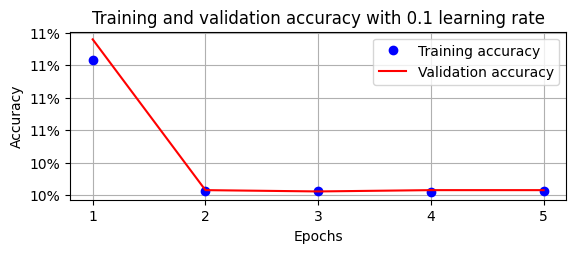

In [33]:
from torchvision import datasets 
import torch 
data_folder = '~/data/FMNIST' # This can be any directory you want to  
# download FMNIST to 
fmnist = datasets.FashionMNIST(data_folder, download=True, train=True) 
tr_images = fmnist.data 
tr_targets = fmnist.targets 
val_fmnist = datasets.FashionMNIST(data_folder, download=True, train=False) 
val_images = val_fmnist.data 
val_targets = val_fmnist.targets 
 
import matplotlib.pyplot as plt 
%matplotlib inline 
import numpy as np 
from torch.utils.data import Dataset, DataLoader 
import torch 
import torch.nn as nn 
device = 'cuda' if torch.cuda.is_available() else 'cpu' 
 
#Hingh Learning Rate 
class FMNISTDataset(Dataset): 
    def __init__(self, x, y): 
        x = x.float() 
        x = x.view(-1,28*28) 
        self.x, self.y = x, y  
    def __getitem__(self, ix): 
        x, y = self.x[ix], self.y[ix]  
        return x.to(device), y.to(device) 
    def __len__(self):  
        return len(self.x) 
 
from torch.optim import SGD, Adam 
def get_model(): 
    model = nn.Sequential( 
        nn.Linear(28 * 28, 1000), 
        nn.ReLU(), 
        nn.Linear(1000, 10) 
    ).to(device) 
 
    loss_fn = nn.CrossEntropyLoss() 
    optimizer = Adam(model.parameters(), lr=1e-1) 
    return model, loss_fn, optimizer 
 
def train_batch(x, y, model, opt, loss_fn): 
    model.train() 
    prediction = model(x) 
    batch_loss = loss_fn(prediction, y) 
    batch_loss.backward() 
    optimizer.step() 
    optimizer.zero_grad() 
    return batch_loss.item() 
def accuracy(x, y, model): 
    model.eval() 
    # this is the same as @torch.no_grad  
    # at the top of function, only difference 
    # being, grad is not computed in the with scope 
    with torch.no_grad(): 
        prediction = model(x) 
    max_values, argmaxes = prediction.max(-1) 
    is_correct = argmaxes == y 
    return is_correct.cpu().numpy().tolist() 
 
def get_data():  
    train = FMNISTDataset(tr_images, tr_targets)  
    trn_dl = DataLoader(train, batch_size=32, shuffle=True) 
    val = FMNISTDataset(val_images, val_targets)  
    val_dl = DataLoader(val, batch_size=len(val_images), shuffle=False) 
    return trn_dl, val_dl 
 
@torch.no_grad() 
def val_loss(x, y, model): 
    prediction = model(x) 
    val_loss = loss_fn(prediction, y) 
    return val_loss.item() 
 
trn_dl, val_dl = get_data() 
model, loss_fn, optimizer = get_model() 
 
train_losses, train_accuracies = [], [] 
val_losses, val_accuracies = [], [] 
for epoch in range(5): 
    print(epoch) 
    train_epoch_losses, train_epoch_accuracies = [], [] 
    for ix, batch in enumerate(iter(trn_dl)): 
        x, y = batch 
        batch_loss = train_batch(x, y, model, optimizer, loss_fn) 
        train_epoch_losses.append(batch_loss)  
    train_epoch_loss = np.array(train_epoch_losses).mean() 
 
    for ix, batch in enumerate(iter(trn_dl)): 
        x, y = batch 
        is_correct = accuracy(x, y, model) 
        train_epoch_accuracies.extend(is_correct) 
    train_epoch_accuracy = np.mean(train_epoch_accuracies) 
    for ix, batch in enumerate(iter(val_dl)): 
        x, y = batch 
        val_is_correct = accuracy(x, y, model) 
        validation_loss = val_loss(x, y, model) 
    val_epoch_accuracy = np.mean(val_is_correct) 
    train_losses.append(train_epoch_loss) 
    train_accuracies.append(train_epoch_accuracy) 
    val_losses.append(validation_loss) 
    val_accuracies.append(val_epoch_accuracy) 
 
epochs = np.arange(5)+1 
import matplotlib.ticker as mtick 
import matplotlib.pyplot as plt 
import matplotlib.ticker as mticker 
%matplotlib inline 
plt.subplot(211) 
plt.plot(epochs, train_losses, 'bo', label='Training loss') 
plt.plot(epochs, val_losses, 'r', label='Validation loss') 
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1)) 
plt.title('Training and validation loss with 0.1 learning rate') 
plt.xlabel('Epochs') 
plt.ylabel('Loss') 
plt.legend() 
plt.grid('off') 
plt.show() 
plt.subplot(212) 
plt.plot(epochs, train_accuracies, 'bo', label='Training accuracy') 
plt.plot(epochs, val_accuracies, 'r', label='Validation accuracy') 
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1)) 
plt.title('Training and validation accuracy with 0.1 learning rate') 
plt.xlabel('Epochs') 
plt.ylabel('Accuracy') 
plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in 
plt.gca().get_yticks()])  
plt.legend() 
plt.grid('off') 
plt.show()

Tốc độ học trung bình: 

0
1
2
3
4


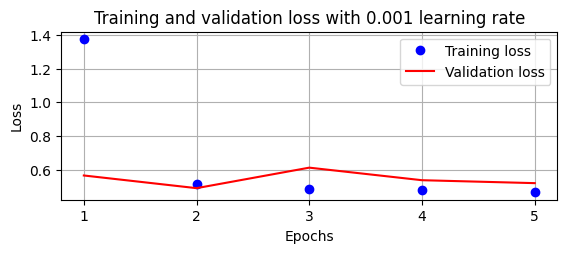

C:\Users\T.Hung\AppData\Local\Temp\ipykernel_26668\3977261901.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in


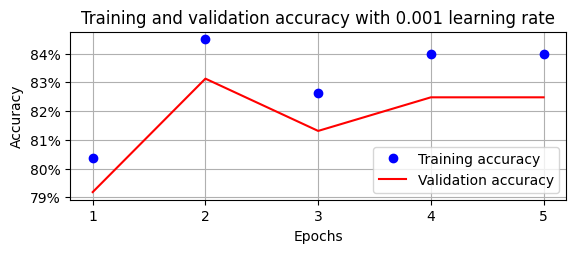

In [34]:
def get_model(): 
    model = nn.Sequential( 
        nn.Linear(28 * 28, 1000), 
        nn.ReLU(), 
        nn.Linear(1000, 10) 
    ).to(device) 
 
    loss_fn = nn.CrossEntropyLoss() 
    optimizer = Adam(model.parameters(), lr=1e-3) 
    return model, loss_fn, optimizer 
trn_dl, val_dl = get_data() 
model, loss_fn, optimizer = get_model() 
 
train_losses, train_accuracies = [], [] 
val_losses, val_accuracies = [], [] 
for epoch in range(5): 
    print(epoch) 
    train_epoch_losses, train_epoch_accuracies = [], [] 
    for ix, batch in enumerate(iter(trn_dl)): 
        x, y = batch 
        batch_loss = train_batch(x, y, model, optimizer, loss_fn)
        train_epoch_losses.append(batch_loss)  
    train_epoch_loss = np.array(train_epoch_losses).mean() 
 
    for ix, batch in enumerate(iter(trn_dl)): 
        x, y = batch 
        is_correct = accuracy(x, y, model) 
        train_epoch_accuracies.extend(is_correct) 
    train_epoch_accuracy = np.mean(train_epoch_accuracies) 
    for ix, batch in enumerate(iter(val_dl)): 
        x, y = batch 
        val_is_correct = accuracy(x, y, model) 
        validation_loss = val_loss(x, y, model) 
    val_epoch_accuracy = np.mean(val_is_correct) 
    train_losses.append(train_epoch_loss) 
    train_accuracies.append(train_epoch_accuracy) 
    val_losses.append(validation_loss) 
    val_accuracies.append(val_epoch_accuracy) 
epochs = np.arange(5)+1 
import matplotlib.ticker as mtick 
import matplotlib.pyplot as plt 
import matplotlib.ticker as mticker 
%matplotlib inline 
plt.subplot(211) 
plt.plot(epochs, train_losses, 'bo', label='Training loss') 
plt.plot(epochs, val_losses, 'r', label='Validation loss') 
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1)) 
plt.title('Training and validation loss with 0.001 learning rate') 
plt.xlabel('Epochs') 
plt.ylabel('Loss') 
plt.legend() 
plt.grid('off') 
plt.show() 
plt.subplot(212) 
plt.plot(epochs, train_accuracies, 'bo', label='Training accuracy') 
plt.plot(epochs, val_accuracies, 'r', label='Validation accuracy') 
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1)) 
plt.title('Training and validation accuracy with 0.001 learning rate') 
plt.xlabel('Epochs') 
plt.ylabel('Accuracy') 
plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in 
plt.gca().get_yticks()])  
plt.legend() 
plt.grid('off') 
plt.show() 


Tốc độ học thấp


0
1
2
3
4


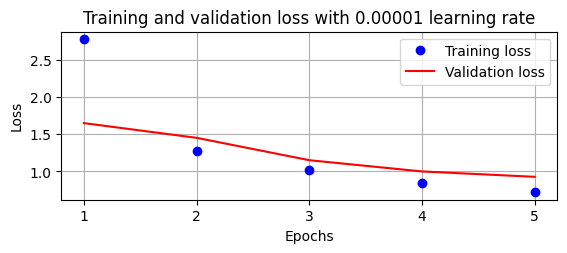

C:\Users\T.Hung\AppData\Local\Temp\ipykernel_26668\697940802.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in


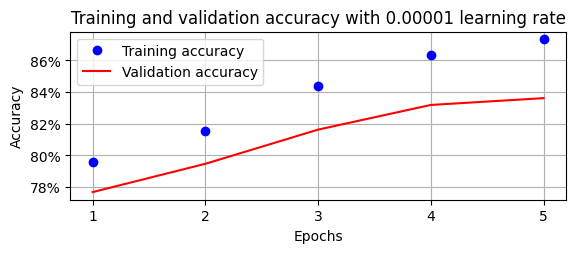

In [35]:
def get_model(): 
    model = nn.Sequential( 
        nn.Linear(28 * 28, 1000), 
        nn.ReLU(), 
        nn.Linear(1000, 10) 
    ).to(device) 
 
    loss_fn = nn.CrossEntropyLoss() 
    optimizer = Adam(model.parameters(), lr=1e-5) 
    return model, loss_fn, optimizer  
trn_dl, val_dl = get_data() 
model, loss_fn, optimizer = get_model() 
 
train_losses, train_accuracies = [], [] 
val_losses, val_accuracies = [], [] 
for epoch in range(5): 
    print(epoch) 
    train_epoch_losses, train_epoch_accuracies = [], [] 
    for ix, batch in enumerate(iter(trn_dl)): 
        x, y = batch 
        batch_loss = train_batch(x, y, model, optimizer, loss_fn) 
        train_epoch_losses.append(batch_loss)  
    train_epoch_loss = np.array(train_epoch_losses).mean() 
 
    for ix, batch in enumerate(iter(trn_dl)): 
        x, y = batch 
        is_correct = accuracy(x, y, model) 
        train_epoch_accuracies.extend(is_correct) 
    train_epoch_accuracy = np.mean(train_epoch_accuracies) 
    for ix, batch in enumerate(iter(val_dl)): 
        x, y = batch 
        val_is_correct = accuracy(x, y, model) 
        validation_loss = val_loss(x, y, model) 
    val_epoch_accuracy = np.mean(val_is_correct) 
    train_losses.append(train_epoch_loss) 
    train_accuracies.append(train_epoch_accuracy) 
    val_losses.append(validation_loss) 
    val_accuracies.append(val_epoch_accuracy) 
epochs = np.arange(5)+1 
import matplotlib.ticker as mtick 
import matplotlib.pyplot as plt 
import matplotlib.ticker as mticker 
%matplotlib inline 
plt.subplot(211) 
plt.plot(epochs, train_losses, 'bo', label='Training loss') 
plt.plot(epochs, val_losses, 'r', label='Validation loss') 
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1)) 
plt.title('Training and validation loss with 0.00001 learning rate') 
plt.xlabel('Epochs') 
plt.ylabel('Loss') 
plt.legend() 
plt.grid('off') 
plt.show() 
plt.subplot(212) 
plt.plot(epochs, train_accuracies, 'bo', label='Training accuracy') 
plt.plot(epochs, val_accuracies, 'r', label='Validation accuracy') 
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1)) 
plt.title('Training and validation accuracy with 0.00001 learning rate') 
plt.xlabel('Epochs') 
plt.ylabel('Accuracy') 
plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in 
plt.gca().get_yticks()])  
plt.legend() 
plt.grid('off') 
plt.show() 